In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

In [2]:
# CSV beolvasása
df = pd.read_csv('hierarchical_demo_data.csv')

print(f"Adatok betöltve, összesen {len(df)} pont")
df.head()

Adatok betöltve, összesen 415 pont


,x,y
0,3.236947,5.709298
1,2.684954,6.435995
2,6.634094,7.734306
3,7.019823,7.020829
4,6.307277,6.911949


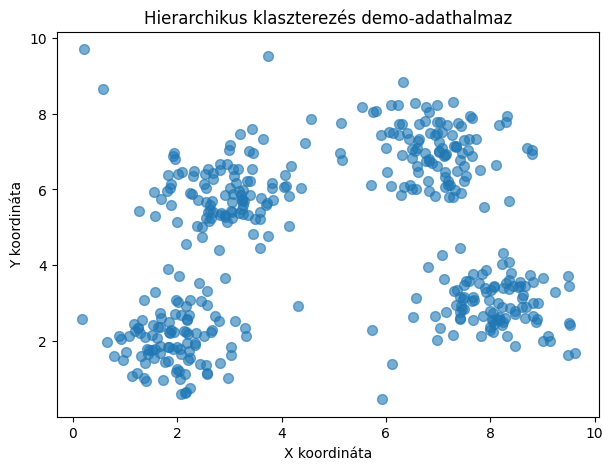

In [3]:
plt.figure(figsize=(7,5))
plt.scatter(df['x'], df['y'], s=50, alpha=0.6)
plt.title("Hierarchikus klaszterezés demo-adathalmaz")
plt.xlabel("X koordináta")
plt.ylabel("Y koordináta")
plt.show()

### Linkage és Ward módszer

- A **linkage** a hierarchikus klaszterezés „munkaanyaga”: minden egyes klaszter-összeolvadást tárol, beleértve a két klaszter azonosítóját, a köztük lévő távolságot, és az új klaszter méretét.
- A dendrogram a linkage mátrix vizualizációja: láthatjuk, hogyan egyesülnek a pontok és klaszterek a távolság függvényében.
- A **Ward módszer** egy linkage stratégia, amely mindig azt az összeolvadást választja, ami a klaszterek **belső varianciáját** a legkevésbé növeli, így homogénebb klasztereket kapunk.
- A linkage tehát lehetővé teszi, hogy **dendrogramot készítsünk és klaszterszámot válasszunk** az adatok alapján.

In [4]:
# Hierarchikus klaszterezés (Ward módszer)
Z = linkage(df[['x', 'y']], method='ward')

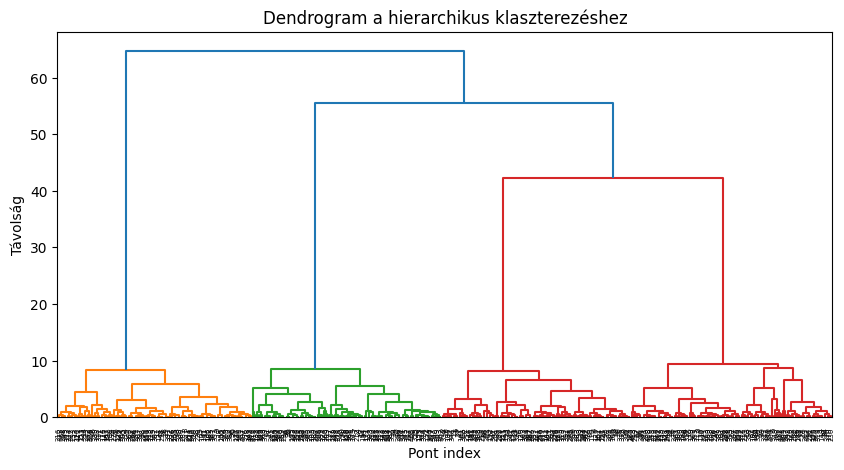

In [5]:
plt.figure(figsize=(10,5))
dendrogram(Z, truncate_mode='level', p=20)  # csak a legfelső ágak (20 szintig)
plt.title("Dendrogram a hierarchikus klaszterezéshez")
plt.xlabel("Pont index")
plt.ylabel("Távolság")
plt.show()

### Klaszterek létrehozása a dendrogram alapján (`fcluster`)

- A `fcluster()` a linkage mátrixból készít tényleges klasztereket.
- **Paraméterek:**
  - `Z` → a linkage mátrix (a dendrogram „munkaanyaga”)
  - `max_clusters` → hány klasztert szeretnénk
  - `criterion='maxclust'` → a dendrogramot úgy vágja, hogy pontosan `max_clusters` klasztert kapjunk
- A függvény visszaad egy **tömböt**, ahol minden pont **klasztercímkét** kap.
- Ezeket a címkéket használhatjuk **scatter plot színezéséhez** vagy további elemzésekhez.

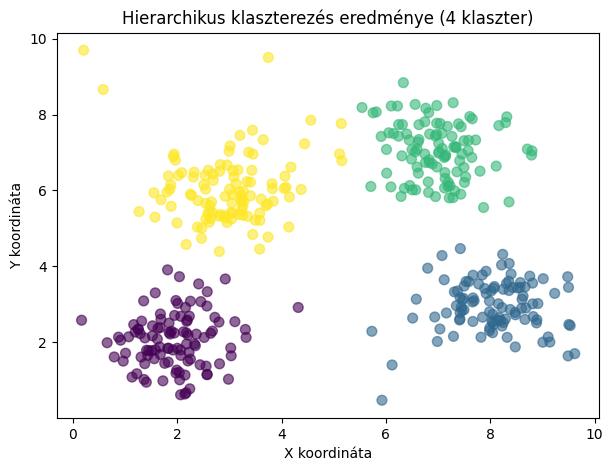

In [6]:
# Példa: 4 klasztert választunk
max_clusters = 4
labels = fcluster(Z, max_clusters, criterion='maxclust')

plt.figure(figsize=(7,5))
plt.scatter(df['x'], df['y'], c=labels, s=50, alpha=0.6)
plt.title(f"Hierarchikus klaszterezés eredménye ({max_clusters} klaszter)")
plt.xlabel("X koordináta")
plt.ylabel("Y koordináta")
plt.show()